In [1]:
import os
import json
import numpy as np
import nibabel as nib
import torch

In [16]:
with open("data_split.json", "r") as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 1000
Validation: 125
Test: 126


In [17]:
train_data = r"Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [18]:
def preprocess_t2f(image):
    # Expected original BraTS shape
    if image.shape != (240, 240, 155):
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image[16:224, 8:232, :]

    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    foreground = image > 0

    if not np.any(foreground):
        raise ValueError("No foreground voxels found")

    upper = np.percentile(image[foreground], 99.9)

    image = np.clip(image, 0, upper)

    image = image / upper

    image[~foreground] = 0

    return image.astype(np.float32)

In [8]:
from torch.utils.data import Dataset, DataLoader

class BraTSDataset(Dataset):
    def __init__(self, subjects, data_dir):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        subject = self.subjects[idx]
        subject_path = os.path.join(self.data_dir, subject)

        files = os.listdir(subject_path)

        t2f_file = [f for f in files if "t2f" in f.lower()][0]

        image = nib.load(
            os.path.join(subject_path, t2f_file)
        ).get_fdata()

        image = preprocess_t2f(image)

        image = torch.from_numpy(image).unsqueeze(0)

        return {
            "image": image,
            "subject": subject
        }

In [9]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))

Dataset size: 1000


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

Batch image shape: torch.Size([1, 1, 208, 224, 160])
Batch dtype: torch.float32
Subject: ['BraTS-GLI-00017-000']
Min: 0.0
Max: 1.0


In [2]:
timesteps = 1000

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, timesteps)

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

In [3]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2

        embeddings = math.log(10000) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings
        )

        embeddings = t[:, None] * embeddings[None, :]

        embeddings = torch.cat(
            (embeddings.sin(), embeddings.cos()),
            dim=1
        )

        return embeddings

In [4]:
class ResBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.conv1 = nn.Conv3d(
            in_channels, out_channels,
            kernel_size=3, padding=1
        )

        self.conv2 = nn.Conv3d(
            out_channels, out_channels,
            kernel_size=3, padding=1
        )

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:
            self.residual = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x, t):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        time_emb = self.time_mlp(t)
        time_emb = time_emb[:, :, None, None, None]

        h = h + time_emb

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + self.residual(x)

In [5]:
class DownBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        self.resblock = ResBlock3D(
            in_channels,
            out_channels,
            time_dim
        )

        self.downsample = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t):
        h = self.resblock(x, t)

        down = self.downsample(h)

        return h, down


class UpBlock3D(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        time_dim
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.resblock = ResBlock3D(
            out_channels + skip_channels,
            out_channels,
            time_dim
        )

    def forward(self, x, skip, t):
        x = self.upsample(x)

        x = torch.cat([x, skip], dim=1)

        x = self.resblock(x, t)

        return x

In [6]:
class UNet3D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=16,
        time_dim=128
    ):
        super().__init__()

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.input_conv = nn.Conv3d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        self.down1 = DownBlock3D(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.down2 = DownBlock3D(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.down3 = DownBlock3D(
            base_channels * 4,
            base_channels * 8,
            time_dim
        )

        self.mid = ResBlock3D(
            base_channels * 8,
            base_channels * 8,
            time_dim
        )

        self.up3 = UpBlock3D(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 4,
            time_dim=time_dim
        )

        self.up2 = UpBlock3D(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 2,
            time_dim=time_dim
        )

        self.up1 = UpBlock3D(
            in_channels=base_channels * 2,
            skip_channels=base_channels * 2,
            out_channels=base_channels,
            time_dim=time_dim
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x, t):
        t = self.time_embedding(t)

        x = self.input_conv(x)

        skip1, x = self.down1(x, t)
        skip2, x = self.down2(x, t)
        skip3, x = self.down3(x, t)

        x = self.mid(x, t)

        x = self.up3(x, skip3, t)
        x = self.up2(x, skip2, t)
        x = self.up1(x, skip1, t)

        x = self.output_conv(x)

        return x

In [22]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    device = x0.device

    sqrt_alpha_cumprod_device = sqrt_alphas_cumprod.to(device)
    sqrt_one_minus_alpha_cumprod_device = (
        sqrt_one_minus_alphas_cumprod.to(device)
    )

    sqrt_alpha_hat = (
        sqrt_alpha_cumprod_device[t]
        .view(-1, 1, 1, 1, 1)
    )

    sqrt_one_minus_alpha_hat = (
        sqrt_one_minus_alpha_cumprod_device[t]
        .view(-1, 1, 1, 1, 1)
    )

    xt = (
        sqrt_alpha_hat * x0
        + sqrt_one_minus_alpha_hat * noise
    )

    return xt, noise

In [39]:
def train_ddpm(
    model,
    train_loader,
    epochs,
    optimizer,
    device,
    checkpoint_dir="checkpoints"
):
    import os

    os.makedirs(checkpoint_dir, exist_ok=True)

    model.train()

    loss_history = []

    # Move diffusion schedule to the same device once
    sqrt_alpha_cumprod_device = sqrt_alphas_cumprod.to(device)
    sqrt_one_minus_alpha_cumprod_device = (
        sqrt_one_minus_alphas_cumprod.to(device)
    )

    for epoch in range(epochs):
        epoch_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):
            x0 = batch["image"].to(device)

            t = torch.randint(
                0,
                timesteps,
                (x0.shape[0],),
                device=device
            )

            noise = torch.randn_like(x0)

            sqrt_alpha_hat = (
                sqrt_alpha_cumprod_device[t]
                .view(-1, 1, 1, 1, 1)
            )

            sqrt_one_minus_alpha_hat = (
                sqrt_one_minus_alpha_cumprod_device[t]
                .view(-1, 1, 1, 1, 1)
            )

            xt = (
                sqrt_alpha_hat * x0
                + sqrt_one_minus_alpha_hat * noise
            )

            predicted_noise = model(xt, t)

            loss = F.mse_loss(
                predicted_noise,
                noise
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if (batch_idx + 1) % 10 == 0:
                print(
                    f"Epoch {epoch + 1}/{epochs} | "
                    f"Batch {batch_idx + 1}/{len(train_loader)} | "
                    f"Loss: {loss.item():.4f}"
                )

        avg_loss = epoch_loss / len(train_loader)

        loss_history.append(avg_loss)

        print(
            f"Epoch {epoch + 1} completed | "
            f"Average loss: {avg_loss:.4f}"
        )

        # Save checkpoint after every epoch
        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"ddpm_epoch_{epoch + 1:03d}.pt"
        )

        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch + 1,
            path=checkpoint_path
        )

        print("Saved:", checkpoint_path)

        np.save(
            os.path.join(checkpoint_dir, "ddpm_loss_history.npy"),
            np.array(loss_history)
        )

In [7]:
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }, path)


def load_checkpoint(model, optimizer, path, device):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return checkpoint["epoch"]

In [8]:
@torch.no_grad()
def sample_ddpm(model, shape, device, sample_timesteps=None):
    model.eval()

    if sample_timesteps is None:
        sample_timesteps = timesteps

    x = torch.randn(shape, device=device)

    for t in reversed(range(sample_timesteps)):
        t_batch = torch.full(
            (shape[0],),
            t,
            device=device,
            dtype=torch.long
        )

        beta_t = betas[t].to(device)
        alpha_t = alphas[t].to(device)
        alpha_hat_t = alphas_cumprod[t].to(device)

        predicted_noise = model(x, t_batch)

        model_mean = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            - (
                beta_t
                / torch.sqrt(1 - alpha_hat_t)
            ) * predicted_noise
        )

        if t > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.sqrt(beta_t) * noise
        else:
            x = model_mean

    return x

In [42]:
device = torch.device("cuda")

model = UNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    time_dim=128
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
train_ddpm(
    model=model,
    train_loader=train_loader,
    epochs=10,
    optimizer=optimizer,
    device=device,
    checkpoint_dir="checkpoints"
)

In [9]:
device = torch.device("cuda")

model = UNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    time_dim=128
).to(device)

loaded_epoch = load_checkpoint(
    model=model,
    optimizer=None,
    path="checkpoints/ddpm_epoch_010.pt",
    device=device
)

model.eval()

print("Loaded epoch:", loaded_epoch)
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Loaded epoch: 10
Device: cuda
GPU: NVIDIA A40


In [10]:
generated = sample_ddpm(
    model=model,
    shape=(1, 1, 208, 224, 160),
    device=device
)

print("Generated shape:", generated.shape)
print("Min:", generated.min().item())
print("Max:", generated.max().item())
print("NaN:", torch.isnan(generated).any().item())

Generated shape: torch.Size([1, 1, 208, 224, 160])
Min: -0.08286502212285995
Max: 2.8424532413482666
NaN: False


In [11]:
generated_np = generated[0, 0].detach().cpu().numpy()

nib.save(
    nib.Nifti1Image(generated_np, affine=np.eye(4)),
    "ddpm_generated_sample.nii.gz"
)

print("Saved: ddpm_generated_sample.nii.gz")

Saved: ddpm_generated_sample.nii.gz


In [13]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 143.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 121.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 124.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


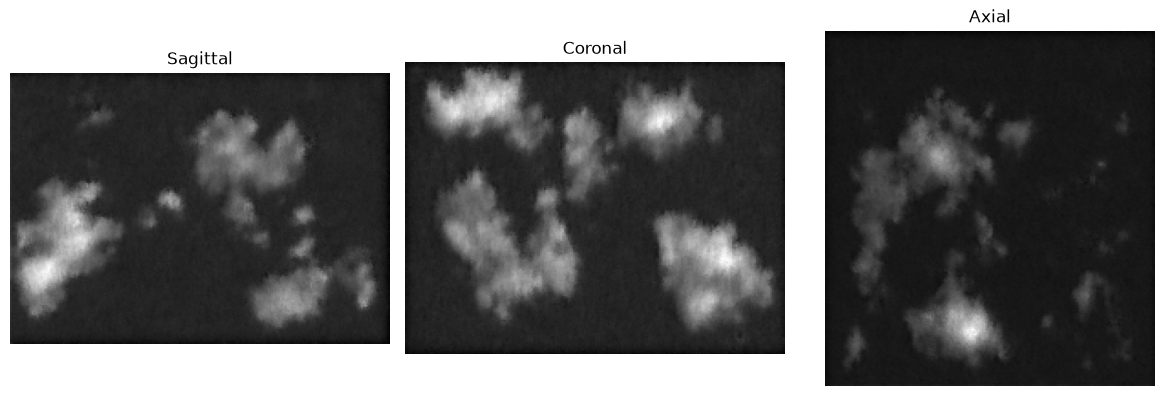

In [14]:
import matplotlib.pyplot as plt

x_mid = generated_np.shape[0] // 2
y_mid = generated_np.shape[1] // 2
z_mid = generated_np.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(generated_np[x_mid, :, :].T, cmap="gray", origin="lower")
axes[0].set_title("Sagittal")
axes[0].axis("off")

axes[1].imshow(generated_np[:, y_mid, :].T, cmap="gray", origin="lower")
axes[1].set_title("Coronal")
axes[1].axis("off")

axes[2].imshow(generated_np[:, :, z_mid].T, cmap="gray", origin="lower")
axes[2].set_title("Axial")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [19]:
subject = train_subjects[0]
subject_path = os.path.join(train_data, subject)

files = os.listdir(subject_path)
t2f_file = [f for f in files if "t2f" in f.lower()][0]

real_t2f = nib.load(
    os.path.join(subject_path, t2f_file)
).get_fdata()

real_processed = preprocess_t2f(real_t2f)

print("Subject:", subject)
print("Shape:", real_processed.shape)
print("Min:", real_processed.min())
print("Max:", real_processed.max())

Subject: BraTS-GLI-00240-000
Shape: (208, 224, 160)
Min: 0.0
Max: 1.0


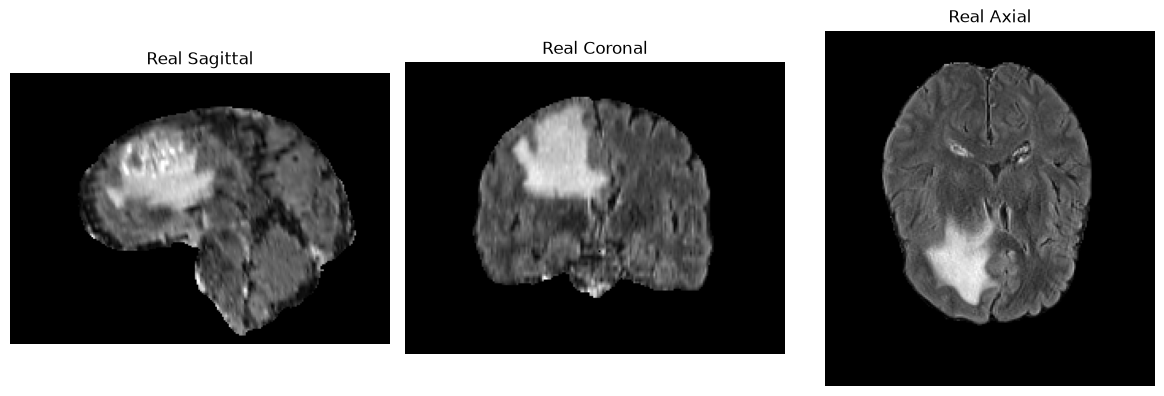

In [20]:
x_mid = real_processed.shape[0] // 2
y_mid = real_processed.shape[1] // 2
z_mid = real_processed.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(
    real_processed[x_mid, :, :].T,
    cmap="gray",
    origin="lower"
)
axes[0].set_title("Real Sagittal")
axes[0].axis("off")

axes[1].imshow(
    real_processed[:, y_mid, :].T,
    cmap="gray",
    origin="lower"
)
axes[1].set_title("Real Coronal")
axes[1].axis("off")

axes[2].imshow(
    real_processed[:, :, z_mid].T,
    cmap="gray",
    origin="lower"
)
axes[2].set_title("Real Axial")
axes[2].axis("off")

plt.tight_layout()
plt.show()